# Chapter 266 - Copulas and Dependence Structures

**Part VIII - Probability**

Independence is the exception, not the rule. Copulas separate marginal behavior from dependence, giving a modular way to build joint distributions. Sklar's theorem guarantees this decomposition always exists.

## 1. Why Marginals Are Not Enough

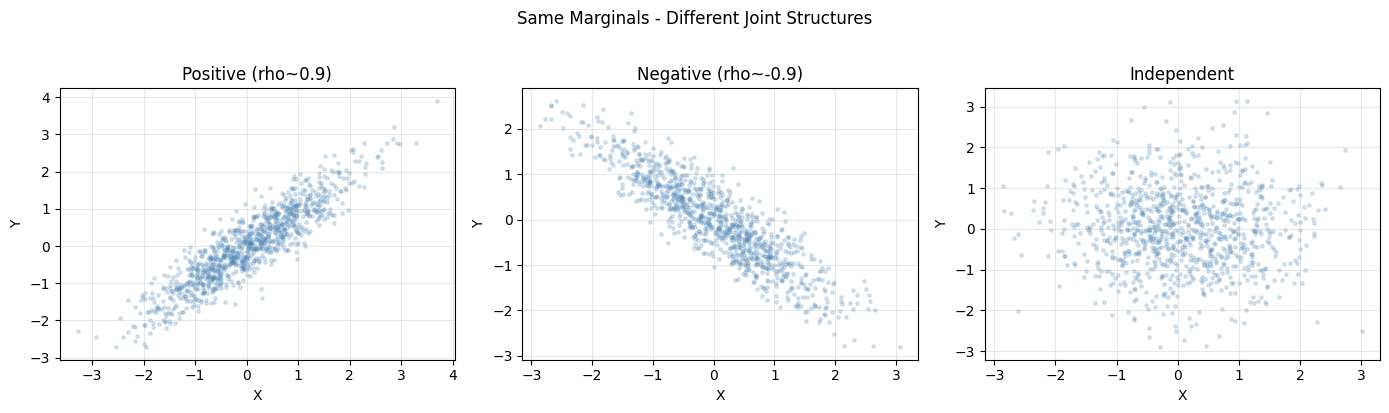

All three datasets have marginals ~ N(0,1) but different joint structure.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, kendalltau, spearmanr

rng = np.random.default_rng(0)

n = 1000
Z1, Z2 = rng.multivariate_normal([0, 0], [[1, 0.9], [0.9, 1]], n).T
Z3, Z4 = rng.multivariate_normal([0, 0], [[1, -0.9], [-0.9, 1]], n).T
Z5 = rng.normal(0, 1, n); Z6 = rng.normal(0, 1, n)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (X, Y), title in zip(axes,
        [(Z1, Z2), (Z3, Z4), (Z5, Z6)],
        ["Positive (rho~0.9)", "Negative (rho~-0.9)", "Independent"]):
    ax.scatter(X, Y, alpha=0.2, s=6, color="steelblue")
    ax.set_title(title); ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.grid(alpha=0.3)
plt.suptitle("Same Marginals - Different Joint Structures", y=1.02)
plt.tight_layout(); plt.show()
print("All three datasets have marginals ~ N(0,1) but different joint structure.")


## 2. Sklar's Theorem and the Copula

For any joint CDF H(x,y) with marginals F(x) and G(y), there exists a copula C such that H(x,y) = C(F(x), G(y)). Transform each marginal to Uniform[0,1] via the probability integral transform. What remains IS the copula.

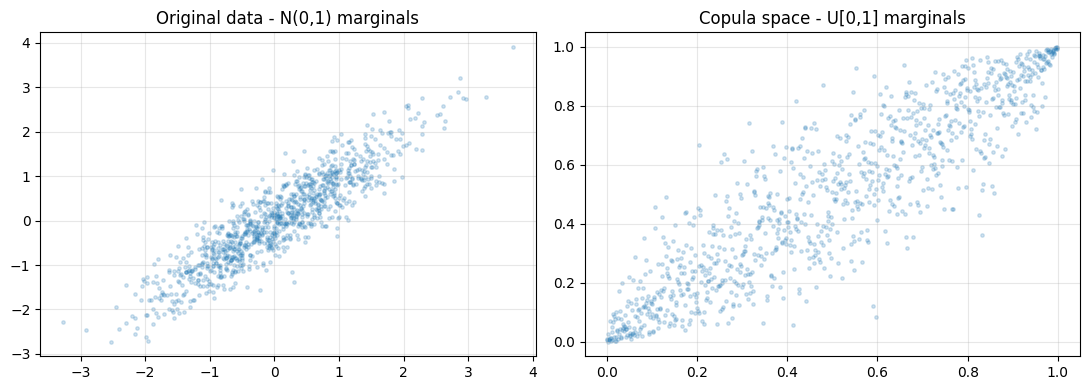

Copula space reveals pure dependence structure stripped of marginals.


In [2]:
def to_uniform(x):
    n = len(x)
    ranks = np.argsort(np.argsort(x))
    return (ranks + 1) / (n + 1)

U1 = to_uniform(Z1); U2 = to_uniform(Z2)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(Z1, Z2, alpha=0.2, s=6)
axes[0].set_title("Original data - N(0,1) marginals")
axes[1].scatter(U1, U2, alpha=0.2, s=6)
axes[1].set_title("Copula space - U[0,1] marginals")
for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("Copula space reveals pure dependence structure stripped of marginals.")


## 3. The Gaussian Copula

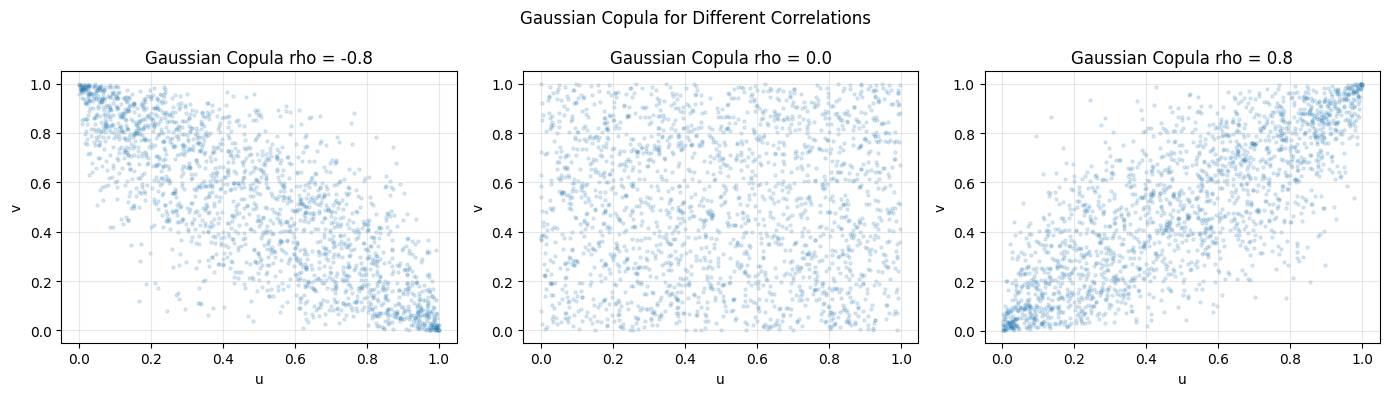

In [3]:
from scipy.stats import norm as snorm

def gaussian_copula_sample(n, rho, rng):
    Z = rng.multivariate_normal([0, 0], [[1, rho], [rho, 1]], n)
    U = snorm.cdf(Z[:, 0])
    V = snorm.cdf(Z[:, 1])
    return U, V

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, rho in zip(axes, [-0.8, 0.0, 0.8]):
    U, V = gaussian_copula_sample(2000, rho, rng)
    ax.scatter(U, V, alpha=0.15, s=5)
    ax.set_title(f"Gaussian Copula rho = {rho}")
    ax.set_xlabel("u"); ax.set_ylabel("v"); ax.grid(alpha=0.3)
plt.suptitle("Gaussian Copula for Different Correlations")
plt.tight_layout(); plt.show()


## 4. The Clayton Copula - Tail Dependence

Clayton copula: C(u,v;theta) = (u^{-theta} + v^{-theta} - 1)^{-1/theta}. Exhibits lower-tail dependence. Used in credit risk modeling.

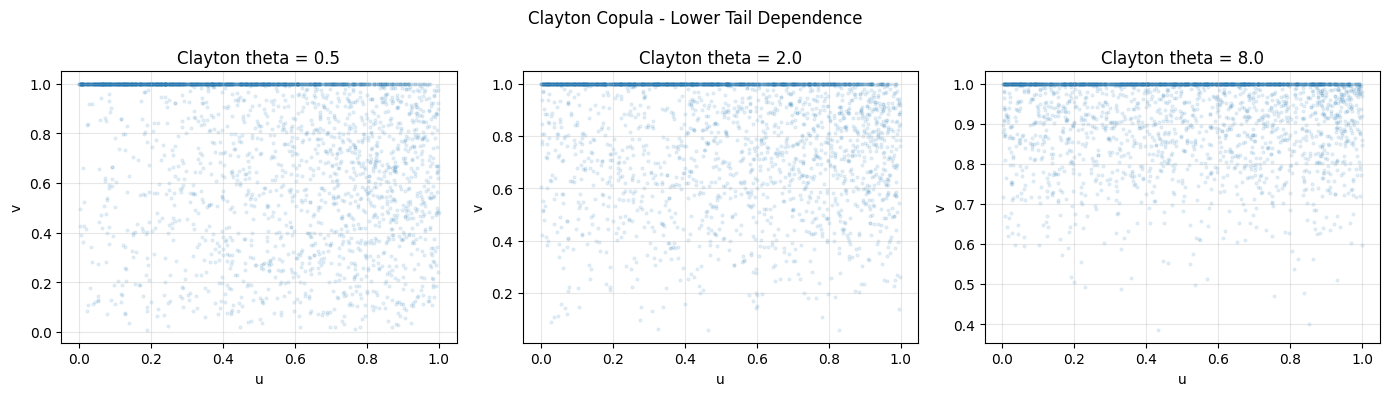

Extreme values cluster in lower-left corner: lower tail dependence.


In [4]:
def clayton_copula_sample(n, theta, rng):
    u = rng.uniform(0, 1, n)
    p = rng.uniform(0, 1, n)
    # Closed-form inverse for Clayton conditional
    inner = p ** (-theta / (1 + theta)) - 1 + u ** theta
    inner = np.maximum(inner, 1e-12)
    v = inner ** (-1 / theta)
    return np.clip(u, 1e-9, 1-1e-9), np.clip(v, 1e-9, 1-1e-9)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, theta in zip(axes, [0.5, 2.0, 8.0]):
    U, V = clayton_copula_sample(3000, theta, rng)
    ax.scatter(U, V, alpha=0.1, s=4)
    ax.set_title(f"Clayton theta = {theta}")
    ax.set_xlabel("u"); ax.set_ylabel("v"); ax.grid(alpha=0.3)
plt.suptitle("Clayton Copula - Lower Tail Dependence")
plt.tight_layout(); plt.show()
print("Extreme values cluster in lower-left corner: lower tail dependence.")


## 5. Rank Correlation: Kendall tau and Spearman rho

Pearson correlation measures linear dependence and changes with marginals. Rank correlations are copula properties - invariant to monotone marginal transformations.

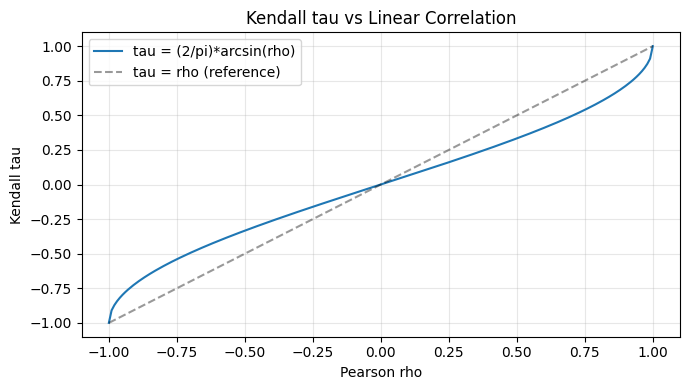

rho=-0.8  tau_predicted=-0.5903  tau_empirical=-0.5933  spearman=-0.7892
rho=+0.0  tau_predicted=+0.0000  tau_empirical=-0.0088  spearman=-0.0132
rho=+0.5  tau_predicted=+0.3333  tau_empirical=+0.3462  spearman=+0.4996
rho=+0.9  tau_predicted=+0.7129  tau_empirical=+0.7102  spearman=+0.8883


In [5]:
rho_vals = np.linspace(-1, 1, 200)
tau_theory = 2 / np.pi * np.arcsin(rho_vals)
plt.figure(figsize=(7, 4))
plt.plot(rho_vals, tau_theory, label="tau = (2/pi)*arcsin(rho)")
plt.plot([-1, 1], [-1, 1], "k--", alpha=0.4, label="tau = rho (reference)")
plt.xlabel("Pearson rho"); plt.ylabel("Kendall tau")
plt.title("Kendall tau vs Linear Correlation"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

for rho in [-0.8, 0.0, 0.5, 0.9]:
    U, V = gaussian_copula_sample(5000, rho, rng)
    tau_emp, _ = kendalltau(U, V)
    tau_pred   = 2 / np.pi * np.arcsin(rho)
    spr, _     = spearmanr(U, V)
    print(f"rho={rho:+.1f}  tau_predicted={tau_pred:+.4f}  tau_empirical={tau_emp:+.4f}  spearman={spr:+.4f}")


## 6. Building Joint Models with Custom Marginals

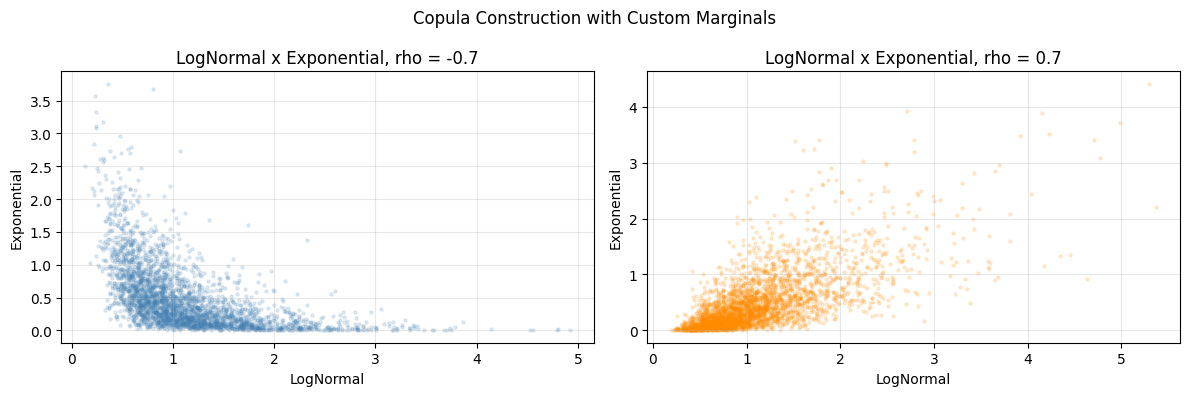

Copula lets you combine ANY marginal distributions.


In [6]:
from scipy.stats import lognorm, expon

def joint_sample_via_copula(n, rho, rng):
    U, V = gaussian_copula_sample(n, rho, rng)
    X = lognorm.ppf(U, s=0.5, scale=1.0)
    Y = expon.ppf(V, scale=0.5)
    return X, Y

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, rho, col in zip(axes, [-0.7, 0.7], ["steelblue", "darkorange"]):
    X, Y = joint_sample_via_copula(3000, rho, rng)
    ax.scatter(X, Y, alpha=0.15, s=5, color=col)
    ax.set_title(f"LogNormal x Exponential, rho = {rho}")
    ax.set_xlabel("LogNormal"); ax.set_ylabel("Exponential"); ax.grid(alpha=0.3)
plt.suptitle("Copula Construction with Custom Marginals")
plt.tight_layout(); plt.show()
print("Copula lets you combine ANY marginal distributions.")


## 7. Summary

Copulas decouple two questions:
1. What are the individual distributions? (marginals)
2. How do they co-move? (copula)

Rank correlations (Kendall tau, Spearman rho) are the natural summary statistics.

*(builds on ch245 - Conditional Probability, ch247 - Random Variables)*

## 8. Forward References

- **ch277 - Correlation**: Pearson vs rank correlation in data analysis.
- **ch283 - Clustering**: multivariate dependence in mixture models.
- **ch299 - Capstone**: multivariate feature dependence in AI systems.